# Software Implementation: Fetal State Classification using FDFI

**Journal of Statistical Software — Case Study Notebook (Section 5)**  
**Package:** `fdfi` — Flow-Disentangled Feature Importance  
**Dataset:** UCI Cardiotocography (CTG) Dataset  

---

## 1. Introduction and Motivation

Cardiotocography (CTG) is a clinical monitoring technique that records fetal heart rate (FHR)
and uterine contractions to assess fetal well-being. The UCI CTG dataset contains 2,126
measurements across 21 morphological and statistical features — including FHR Mean, Mode,
Median, and Variance — that are highly collinear by construction: a mean, median, and mode
measured on the same physiological signal will necessarily co-move.

This notebook uses a binary clinical endpoint: **Normal** versus **Other**, where Other
combines Suspect and Pathological cases. The fitted black-box model estimates
$P(\mathrm{Other}\mid X)$, and FDFI explains that fitted prediction function. The resulting
feature importance values should therefore be read as model-level associations, not as causal
physiological effects.

The visualization cells use the updated `fdfi.plots` helpers from v0.0.8:
`correlation_heatmap`, `summary_bar`, `confidence_interval_plot`, `diagnostics_plot`, and an
optional `summary_plot` for per-sample attributions.


In [1]:
%matplotlib inline

# Keep numerical backends conservative during full-notebook execution.
import os
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('VECLIB_MAXIMUM_THREADS', '1')
os.environ.setdefault('NUMEXPR_NUM_THREADS', '1')

# Install notebook-only dependencies used below.
%pip install -q statsmodels adjustText

# ── Install fdfi package if needed ──────────────────────────────────────────
import sys
sys.path.insert(0, os.path.abspath('..'))
import fdfi
print(fdfi.__version__)

# Keep notebook execution stable on small local machines.
try:
    import torch
    torch.set_num_threads(1)
    torch.set_num_interop_threads(1)
except Exception:
    pass

from fdfi.explainers import FlowExplainer

# ── Standard library ─────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Third-party: data & modelling ────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


# ── Reproducibility ──────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Environment initialised successfully.')

Note: you may need to restart the kernel to use updated packages.


0.0.8


Environment initialised successfully.


---

## 2. Data Acquisition and Pre-processing

The dataset is sourced directly from the UCI Machine Learning Repository. The original
spreadsheet contains header and footer rows that are handled during loading. Features are
extracted from columns 11–31 (1-based) of the CTG worksheet, and the original NSP label is
converted into a binary endpoint:

| Original NSP | Clinical label | Binary target |
|:---:|:---|:---:|
| 1 | Normal | 0 |
| 2 | Suspect | 1 |
| 3 | Pathological | 1 |

The case study uses the full CTG dataset for model fitting and FDFI analysis. We do not split
into train and test sets here because the goal is to explain the fitted predictor used in the
case study rather than to estimate out-of-sample clinical performance.


In [2]:
# ── 2.1  Load from UCI repository ────────────────────────────────────────────
CTG_URL = (
    'https://archive.ics.uci.edu/ml/machine-learning-databases/00193/CTG.xls'
)

print('Downloading CTG dataset from UCI ...')
raw = pd.read_excel(CTG_URL, sheet_name='Data', skiprows=1, header=0)
print(f'  Raw shape (before cleaning): {raw.shape}')

# ── 2.2  Extract feature matrix X and binary target vector y ─────────────────
X_raw = raw.iloc[:, 10:31].copy()
y_raw = raw['NSP'].copy()

data = pd.concat([X_raw, y_raw], axis=1)

feature_names = [
    'LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV',
    'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean',
    'Median', 'Variance', 'Tendency'
]
data.columns = feature_names + ['NSP']

# ── 2.3  Data cleaning, type conversion, and binary endpoint ─────────────────
data = data.apply(pd.to_numeric, errors='coerce')
data.dropna(inplace=True)
data['NSP'] = data['NSP'].astype(int)
data['Other'] = (data['NSP'] != 1).astype(int)

X = data[feature_names].values
y = data['Other'].values

print(f'  Cleaned shape : {data.shape}')
print(f'  Features ({len(feature_names)}): {feature_names}')
print('\n  Original target distribution (NSP):')
print(
    data['NSP']
    .value_counts()
    .sort_index()
    .rename({1: 'Normal (1)', 2: 'Suspect (2)', 3: 'Pathological (3)'})
)
print('\n  Binary target distribution:')
print(
    pd.Series(y)
    .value_counts()
    .sort_index()
    .rename({0: 'Normal = 0', 1: 'Other = 1'})
)


  Raw shape (before cleaning): (2129, 46)
  Cleaned shape : (2126, 23)
  Features (21): ['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance', 'Tendency']

  Original target distribution (NSP):
NSP
Normal (1)          1655
Suspect (2)          295
Pathological (3)     176
Name: count, dtype: int64

  Binary target distribution:
Normal = 0    1655
Other = 1      471
Name: count, dtype: int64


### 2.1 Collinearity Diagnostics

Before modelling we verify the collinearity structure that motivates FDFI. The FHR summary
statistics (`Mode`, `Mean`, `Median`) are expected to correlate strongly with one another and
with `LB` (baseline FHR) — precisely the scenario in which KernelSHAP attribution collapses
and produces unreliable feature rankings.

Figure 1 uses `correlation_heatmap` to diagnose CTG feature collinearity directly from the
training design matrix. The saved PDF is used as the collinearity diagnostic figure for the
case study.


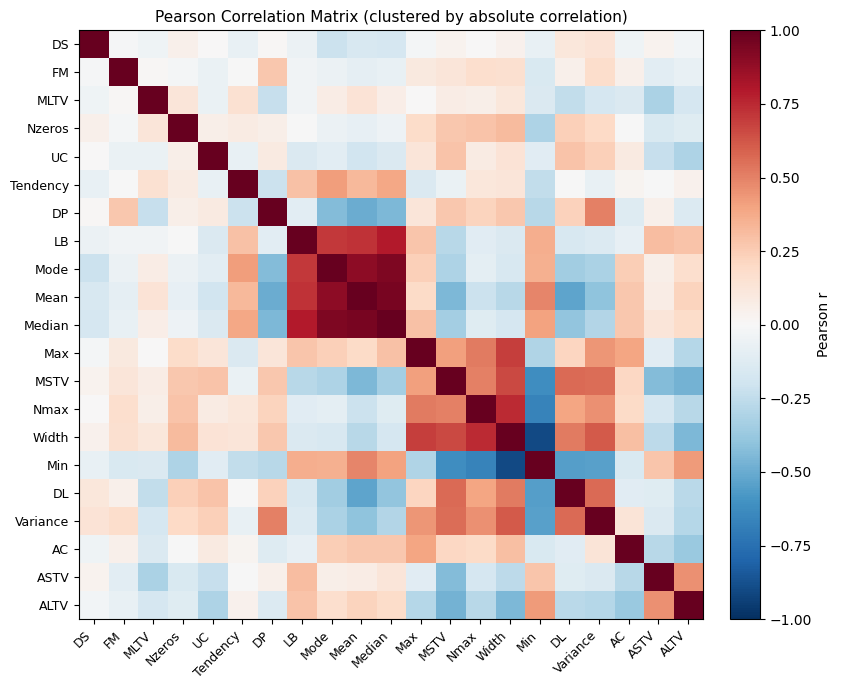

In [3]:
from fdfi.plots import correlation_heatmap

# Plot correlation heatmap using fdfi.plots.correlation_heatmap
fig, ax, feature_names_reordered = correlation_heatmap(
    X, feature_names, 
    savepath='fig1_correlation_matrix.pdf'
)
plt.show()

---

## 3. Implementation Details

The `fdfi` package is organised into three cooperating layers: a **disentanglement engine**
(`fdfi.models`) that learns a non-linear bijective map between the observed feature space and
an independent latent space; a **feature attribution layer** (`fdfi.explainers`) that computes
statistically rigorous importance scores with uncertainty quantification; and a **reliability
diagnostics layer** (`fdfi.utils`) that certifies the validity of the disentanglement before
any attributions are trusted. 


### 3.1 Disentangling Correlations via Flow Matching

The fundamental obstacle to reliable feature attribution in the CTG domain — and in any
domain characterised by strong inter-feature correlation — is that standard Shapley estimators
(e.g., KernelSHAP) marginalise over a background distribution that does not factorise. When
features $X_1, \ldots, X_d$ are dependent, the marginal interventions
$\tilde{X}^{(j)} = (X_{-j}, \tilde{X}_j)$ used in the Shapley integral draw counterfactuals
from outside the data manifold, producing attribution scores that conflate genuine feature
importance with distributional artefacts.

`fdfi` resolves this by learning a **Continuous Normalising Flow** $T_\theta$ — implemented
in `fdfi.models.FlowMatchingModel` — that transports the empirical distribution $p(X)$ to a
standard Gaussian:

$$T_\theta : \mathcal{X} \longrightarrow \mathcal{Z}, \qquad Z = T_\theta(X),
\quad Z \sim \mathcal{N}(\mathbf{0}, I_d).$$

The network is trained via the **Flow Matching** objective of Lipman et al. (2022), which
regresses a time-conditioned velocity field $v_\theta(x, t)$ against the target vector field
of a straight-path interpolant between a Gaussian source $x_0 \sim \mathcal{N}(0, I)$ and a
data sample $x_1 \sim p(X)$:

$$\mathcal{L}(\theta) =
\mathbb{E}_{t, x_0, x_1}\bigl[\|v_\theta(x_t, t) - (x_1 - (1 - \sigma_\mathrm{min})\,x_0)\|^2\bigr],
\quad x_t = (1 - (1-\sigma_\mathrm{min})\,t)\,x_0 + t\,x_1.$$

The small constant $\sigma_\mathrm{min} > 0$ prevents path degeneracy near $t = 0$.
At inference time, $T_\theta$ and its inverse $T_\theta^{-1}$ are obtained by integrating the
learned ODE forward ($t: 0 \to 1$, i.e., $\mathcal{Z} \to \mathcal{X}$) or backward
($t: 1 \to 0$, i.e., $\mathcal{X} \to \mathcal{Z}$) using an adaptive Runge–Kutta solver.

The velocity field is parameterised by a time-conditioned residual MLP (`FlowModelResNet`). 
A time embedding $\psi(t) \in \mathbb{R}^{d_t}$ is concatenated with the input $x_t$ before 
the first linear projection, allowing the network to modulate its behaviour continuously over 
the integration interval $[0, 1]$. The ODE is solved with `torchdiffeq.odeint` using the 
`dopri5` (Dormand–Prince) adaptive solver; solver tolerances `rtol` and `atol` are exposed as 
keyword arguments to `sample_batch()` for reproducibility auditing.

**Table 1.** Key constructor and fitting parameters of `FlowMatchingModel`.

| Parameter | Type | Default | Description |
|:---|:---|:---:|:---|
| `X` | `ndarray` | — | Training data; sets the target distribution $p(X)$. |
| `dim` | `int` | — | Feature dimensionality $d$. |
| `hidden_dim` | `int` | `64` | Width of each residual MLP block. |
| `time_embed_dim` | `int` | `32` | Dimension of the sinusoidal time embedding. |
| `num_blocks` | `int` | `1` | Number of `ResidualMLPBlock` layers in the trunk. |
| `sigma_min` | `float` | `0.01` | Path-noise floor; prevents degenerate flows near $t=0$. |
| `num_steps` | `int` | `5000` | Training iterations passed to `.fit()`. |
| `verbose` | `bool\|str` | `'final'` | `True`/`'all'`: full progress bar; `'final'`: one-line summary; `False`: silent. |


### 3.2 Robust Feature Attribution and Inference

Given a trained flow $T_\theta$, the `FlowExplainer` class in `fdfi.explainers` implements the
complete FDFI attribution pipeline. Its design follows the SHAP API convention: the explainer
is initialised with a model callable and background data, and importance scores are obtained
by calling the instance on a test array.

**Attribution methodology.** For each feature $j$ and each test point $x^{(i)}$, the
explainer constructs $B$ counterfactual copies $\tilde{x}^{(i,b)}$ (controlled by the
parameter `nsamples`, i.e., $B = \texttt{nsamples}$) by (i) encoding $x^{(i)}$ to
$z^{(i)} = T_\theta(x^{(i)})$, (ii) replacing the $j$-th latent coordinate with a draw
from the marginal $p(Z_j)$ (independence is guaranteed by construction), and (iii) decoding
back to feature space. Two complementary importance measures are computed:

$$\phi_j^\mathrm{CPI}(x^{(i)}) =
\Bigl(f(x^{(i)}) - \tfrac{1}{B}\textstyle\sum_{b=1}^B f(\tilde{x}^{(i,b)})\Bigr)^2,
\tag{1}$$

$$\phi_j^\mathrm{SCPI}(x^{(i)}) =
\mathrm{Var}_b\!\bigl[f(\tilde{x}^{(i,b)})\bigr].
\tag{2}$$

CPI (Conditional Permutation Importance) measures the squared prediction gap; SCPI
(Sobol-CPI) measures the conditional output variance and corresponds to the Sobol
total-order sensitivity index. Global importance in latent space is
$\phi_j^Z = \frac{1}{n}\sum_i \phi_j(x^{(i)})$.

**Jacobian back-projection.** To express importance in the original feature space, the
Jacobian $H = \partial X / \partial Z \in \mathbb{R}^{d \times d}$ of the decoder
$T_\theta^{-1}$ is computed via automatic differentiation (averaged over a batch of test
points), and importance is projected as

$$\phi_l^X = \sum_{k=1}^d H_{lk}^2 \cdot \phi_k^Z, \qquad l = 1, \ldots, d.$$

**Variance-floor adjustment.** A critical statistical innovation of `fdfi` is the
**variance-floor** applied to raw bootstrap standard errors before confidence interval
construction. Raw standard errors $\widehat{\mathrm{SE}}_j$ can be unreliably small for
features near the decision boundary or in sparse regions of $\mathcal{Z}$. The `_adjust_se`
method fits a two-component Gaussian mixture (`TwoComponentMixture`) to the empirical
distribution of all $\widehat{\mathrm{SE}}_j$ values, extracts the $q$-th quantile of the
*smaller* component as a floor $\delta$, and inflates each standard error as

$$\mathrm{SE}_j^* = \sqrt{\widehat{\mathrm{SE}}_j^2 + \delta^2}.$$

This ensures that confidence intervals are never artificially narrow due to Monte Carlo
under-sampling (i.e., insufficient $B = \texttt{nsamples}$). A practical significance
margin $m$ — derived analogously from the smaller component of the $\phi_j$ mixture — can
further filter features whose importance, although statistically nonzero, is practically
negligible. Both adjustments are invoked transparently through `conf_int()`.

**Table 2.** Key parameters and return values of `FlowExplainer.__call__()` and `conf_int()`.

| Symbol / Parameter | Role | Description |
|:---|:---|:---|
| `nsamples` ($B$) | Attribution | Monte Carlo draw count per feature per sample. Higher $B$ reduces $\widehat{\mathrm{SE}}$; see variance-floor note above. |
| `method` | Attribution | `'cpi'`: squared prediction gap (Eq. 1); `'scpi'`: output variance (Eq. 2); `'both'`: return both. |
| `sampling_method` | Attribution | `'resample'` (default): draw $Z_j$ from encoded background; `'permutation'`: permute within batch; `'normal'`: $\mathcal{N}(0,1)$; `'condperm'`: residual conditional permutation. |
| `phi_X` | Output | Mean importance in $\mathcal{X}$, shape $(d,)$. |
| `se_X` | Output | Bootstrap standard error of `phi_X`, shape $(d,)$. |
| `alpha` | Inference | Nominal type-I error rate for confidence intervals. |
| `var_floor_method` | Inference | `'mixture'`: data-adaptive floor via GMM; `'fixed'`: fixed $c / \sqrt{n}$ floor. |
| `alternative` | Inference | `'greater'`, `'less'`, or `'two-sided'`. |
| `reject_null` | Output | Boolean array; `True` where $\phi_j > m$ at significance `alpha`. |
| `pvalue` | Output | Asymptotic $p$-values under $H_0: \phi_j \leq m$. |
| `score` | Output | Feature-level or group-level importance estimate returned by `conf_int()`; replaces the old `phi_hat` key in `0.0.5`. |
| `pvalue_adj` | Output | Multiple-testing adjusted p-values, available when `multitest_method` is specified. |
| `groups` | Inference | Optional group definition passed to `conf_int(groups=...)` for group-level clinical feature inference. |
| `multitest_method` | Inference | Optional multiple-testing correction, e.g. `'fdr_bh'`, `'bonferroni'`, or `'holm'`. |


### 3.3 Reliability Metrics and Quality Assurance

A distinctive feature of `fdfi` relative to other XAI libraries is its built-in
**self-certification pipeline**. Before the user inspects any attribution scores, two
complementary diagnostic statistics are automatically computed during explainer
initialisation and stored in `explainer.diagnostics`. This design choice — inspired by the
model-checking tradition in Bayesian statistics (Gelman et al., 2013) — ensures that
attributions are only delivered when the underlying disentanglement can be independently
verified.

Both diagnostics are implemented in `fdfi.utils` and operate on the background data pair
$(X, \hat{X})$ where $\hat{X} = T_\theta^{-1}(T_\theta(X))$ is the round-trip reconstruction.

#### Distance Correlation — Latent Independence

`compute_latent_independence(Z)` computes the full $d \times d$ matrix of pairwise
**distance correlations** (dCor; Székely et al., 2007) among the latent dimensions
$Z_1, \ldots, Z_d$. Unlike Pearson correlation, dCor equals zero *if and only if* two
random variables are statistically independent, making it a rigorous non-parametric
independence certificate.

For each pair $(j, k)$, the function constructs double-centred distance matrices
$\mathcal{A}^{(j)}$ and $\mathcal{A}^{(k)}$ and computes

$$\mathrm{dCor}(Z_j, Z_k) =
\frac{\mathcal{V}^2(Z_j, Z_k)}{\sqrt{\mathcal{V}^2(Z_j, Z_j)\,\mathcal{V}^2(Z_k, Z_k)}},$$

where $\mathcal{V}^2$ is the distance covariance. The scalar summary reported to the user
is the **median off-diagonal dCor**:

$$\widetilde{\mathrm{dCor}} =
\underset{j \neq k}{\mathrm{median}}\;\mathrm{dCor}(Z_j, Z_k).$$

#### Maximum Mean Discrepancy — Distribution Fidelity

`compute_mmd(X_real, X_generated)` measures the **Maximum Mean Discrepancy** between the
original feature distribution $p(X)$ and the round-trip reconstruction $p(\hat{X})$ using
a Gaussian RBF kernel $k(x, x') = \exp(-\|x - x'\|^2 / 2\sigma^2)$:

$$\mathrm{MMD}^2(p, q) =
\mathbb{E}_{x,x'\sim p}[k(x,x')] + \mathbb{E}_{z,z'\sim q}[k(z,z')]
- 2\,\mathbb{E}_{x\sim p,\,z\sim q}[k(x,z)].$$

A low MMD confirms that the flow has not distorted the marginal distribution of $X$:
attributions computed in $\mathcal{Z}$ can be mapped back to $\mathcal{X}$ without
introducing systematic bias.

#### Qualitative Labels and Interpretation

Both metrics are mapped to a three-level qualitative label (`GOOD` / `MODERATE` / `POOR`)
using the `_qualitative_score` helper, which applies the threshold pairs defined in
Table 3. The complete diagnostics payload is accessible at any time via
`explainer.diagnostics` or by calling `explainer.diagnose()`.

**Table 3.** Qualitative label thresholds for `fdfi` reliability diagnostics.
Lower values are better for both metrics.

| Diagnostic | Key | GOOD | MODERATE | POOR |
|:---|:---|:---:|:---:|:---:|
| Latent independence | `latent_independence_median` | $< 0.10$ | $[0.10, 0.25)$ | $\geq 0.25$ |
| Distribution fidelity | `distribution_fidelity_mmd` | $< 0.05$ | $[0.05, 0.15)$ | $\geq 0.15$ |

We recommend treating a `POOR` rating on either metric as a stopping criterion: the flow
should be refit with increased `num_steps`, wider architecture (`hidden_dim`, `num_blocks`),
or a smaller ODE tolerance (`flow_solver_rtol`, `flow_solver_atol`) before any attributions
are interpreted. The `MODERATE` band signals acceptable performance for exploratory analysis
but warrants caution in publication-grade reporting.

**Table 4.** Accessor interface for diagnostics in `fdfi`.

| Method / Attribute | Returns | Description |
|:---|:---|:---|
| `explainer.diagnostics` | `dict` | Auto-populated during `__init__`; contains all keys in Table 3 plus the full `dcor_matrix`. |
| `explainer.diagnose()` | `dict` | Re-runs diagnostics on demand; accepts optional `X_orig` and `Z_full` overrides. |
| `explainer.diagnostics['latent_independence_dcor']` | `ndarray (d, d)` | Full pairwise dCor matrix; useful for identifying specific correlated latent pairs. |

---

## 4. Black-Box Model: Random Forest Classifier

FDFI is model-agnostic: it wraps a fitted prediction function. For this case study, the
black-box model is a random forest classifier trained on the full standardized CTG dataset.
The target is binary (`Normal = 0`, `Other = 1`), and the model wrapper below returns the
predicted probability of the target class `Other`.

Because the CTG dataset is small and the notebook is focused on explaining the fitted
predictor, we report full-data fitting performance rather than held-out test accuracy. The
FDFI estimates explain the fitted random-forest probability function, not the true causal
mechanism generating CTG outcomes.


In [4]:
from sklearn.preprocessing import StandardScaler

# ── 4.1  Full-data standardization ────────────────────────────────────────────
scaler = StandardScaler()
X_values = scaler.fit_transform(X)
y_values = y.astype(int)

# Keep these aliases for downstream explanatory code.
X_train = X_values
X_explain = X_values
y_train = y_values

print(f'Analysis samples : {X_values.shape[0]}')
print(f'Analysis features: {X_values.shape[1]}')

# ── 4.2  Fit classifier on the full CTG dataset ──────────────────────────────
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=3,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
model.fit(X_values, y_values)

# ── 4.3  Full-data performance check ─────────────────────────────────────────
y_pred = model.predict(X_values)
acc = accuracy_score(y_values, y_pred)
print(f'\nBlack-box full-data accuracy: {acc:.4f}')
print('\nClassification report (full data):')
print(classification_report(
    y_values,
    y_pred,
    labels=[0, 1],
    target_names=['Normal (0)', 'Other (1)'],
))


Analysis samples : 2126
Analysis features: 21



Black-box full-data accuracy: 0.9868

Classification report (full data):
              precision    recall  f1-score   support

  Normal (0)       0.99      1.00      0.99      1655
   Other (1)       0.99      0.95      0.97       471

    accuracy                           0.99      2126
   macro avg       0.99      0.97      0.98      2126
weighted avg       0.99      0.99      0.99      2126



---

## 5. FDFI Implementation and Flow Diagnostics

We now initialise `FlowExplainer` on the full standardized CTG feature matrix. Internally,
`FlowExplainer` learns a flow-based map from the observed feature space to an approximately
independent latent space, checks the quality of that transformation, and then computes FDFI
importance for the fitted prediction function.

The diagnostics reported here retain the numeric checks used in the package documentation:

- **MMD** assesses distribution fidelity of the learned transformation.
- **Median distance correlation** assesses latent independence.

The accompanying `diagnostics_plot` summarizes the same diagnostics visually.


[FDFI][INFO] Training flow model...


Training complete: 5000 steps, final loss=1.0271


[FDFI][DIAG] Flow Model Diagnostics
[FDFI][DIAG] Latent independence (median dCor): 0.092509 [GOOD]  -> lower is better
[FDFI][DIAG] Distribution fidelity (MMD):       0.031184 [GOOD]  -> lower is better
  FDFI Flow Diagnostics
  Distribution Fidelity   MMD        : 0.031184
  Latent Independence     median dCor : 0.092509

  MMD  threshold < 0.05  ->  PASS
  dCor threshold < 0.10  ->  PASS


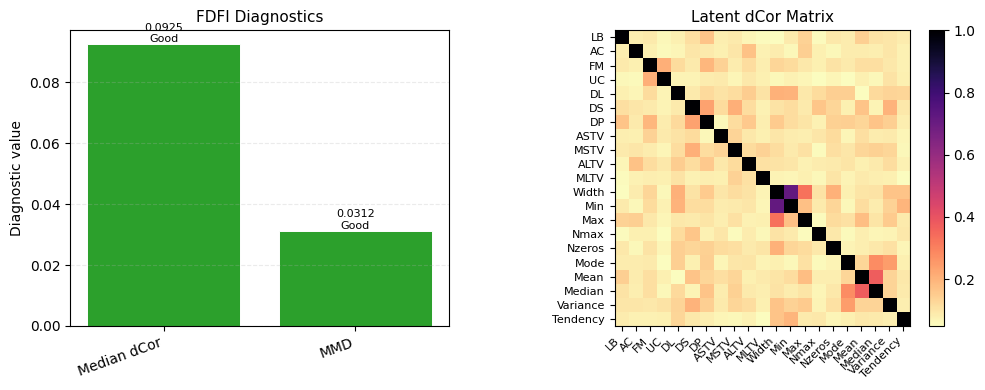

In [5]:
# ── 5.1  Initialise FlowExplainer ─────────────────────────────────────────────
# Return predicted probability of the binary target class Other = 1.
def model_wrapper(X):
    """Return P(Other | X) for the fitted binary random forest."""
    return model.predict_proba(X)[:, 1]

explainer = FlowExplainer(
    model_wrapper,
    X_values,
    nsamples=50,
)

# ── 5.2  Display diagnostics ─────────────────────────────────────────────────
diag = explainer.diagnostics

mmd_val = diag['distribution_fidelity_mmd']
dcor_val = diag['latent_independence_median']

print('=' * 55)
print('  FDFI Flow Diagnostics')
print('=' * 55)
print(f'  Distribution Fidelity   MMD        : {mmd_val:.6f}')
print(f'  Latent Independence     median dCor : {dcor_val:.6f}')
print('=' * 55)

mmd_status  = 'PASS' if mmd_val  < 0.05 else 'WARN — consider refitting flow'
dcor_status = 'PASS' if dcor_val < 0.10 else 'WARN — consider refitting flow'
print(f'\n  MMD  threshold < 0.05  ->  {mmd_status}')
print(f'  dCor threshold < 0.10  ->  {dcor_status}')

from fdfi.plots import diagnostics_plot

fig, axes = diagnostics_plot(
    explainer.diagnostics,
    feature_names=feature_names,
    savepath='fig4_flow_diagnostics.pdf',
)
plt.show()


### 5.2 Diagnostic Interpretation

**MMD (Maximum Mean Discrepancy):** A value below $0.05$ indicates that the Flow network has
successfully mapped the CTG feature distribution $p(X)$ onto a standard Gaussian. This means
that attributions computed in $\mathcal{Z}$ are not contaminated by systematic distribution
mismatch; any score differences between features reflect genuine model sensitivity rather than
artefacts of the transformation.

**Median dCor (Distance Correlation):** Distance correlation equals zero if and only if two
variables are statistically independent (Székely et al., 2007). A median dCor below $0.10$
across all $\binom{d}{2}$ latent pairs certifies that the disentanglement step has succeeded:
the latent dimensions behave as if independent, and the Shapley marginalisation integral is
computed on a valid factored distribution — eliminating correlation distortion at its source.

The `diagnostics_plot` visualization saved as `fig4_flow_diagnostics.pdf` gives a compact
visual version of the same checks: distribution fidelity through MMD and latent independence
through median distance correlation. The numeric thresholds above remain the primary pass/warn
criteria.


---

## 6. Feature Attribution and Visualisation

The random forest and `FlowExplainer` background are fit on the full CTG dataset, and the
main FDFI attribution and inference results below are also computed on all 2,126 CTG
observations. To keep full-notebook execution stable, the attribution calculation uses the
public `FlowExplainer.explain_batches()` method, which evaluates the complete matrix in row
batches and then aggregates the full per-sample UEIF matrix.

A single confidence-interval object is used as the source for both global importance and
interval visualization. This keeps Figure 2 and Figure 3 aligned: the bar chart and
confidence-interval plot use the same feature-level FDFI estimates and standard errors.

For the binary task, positive importance means that replacing or perturbing the corresponding
feature changes the fitted probability of `Other = 1` in the direction measured by the FDFI
procedure. The estimates explain the random-forest prediction function.


In [6]:
# ── 6.1  Compute full-data attributions with public batched API ──────────────
BATCH_SIZE = 50

print(f'Computing FDFI attributions for all {X_values.shape[0]} CTG instances ...')
print('Full-data binary distribution:')
print(pd.Series(y_values).value_counts().sort_index().rename({0: 'Normal = 0', 1: 'Other = 1'}))

results = explainer.explain_batches(X_values, batch_size=BATCH_SIZE)

phi_X = np.asarray(results['phi_X'])
se_X = np.asarray(results['se_X'])
per_sample_phi_X = np.asarray(explainer.ueifs_X)

print(f"results['phi_X'].shape: {phi_X.shape}")
print(f"results['se_X'].shape: {se_X.shape}")
print(f"explainer.ueifs_X shape: {per_sample_phi_X.shape}")

ci_df = explainer.conf_int(
    alpha=0.05,
    target='X',
    alternative='greater',
    multitest_method='fdr_bh',
)

global_phi = np.asarray(ci_df['score'])
global_se = np.asarray(ci_df['se'])

importance_order = np.argsort(-global_phi, kind='stable')
ci_for_plot = dict(ci_df)
ci_for_plot['ranking'] = np.empty_like(importance_order)
ci_for_plot['ranking'][importance_order] = np.arange(1, len(importance_order) + 1)

importance_df = (
    pd.DataFrame({
        'feature': feature_names,
        'phi': global_phi,
        'se': global_se,
        'reject_fdr': ci_df['reject_null'],
        'pvalue_adj': ci_df['pvalue_adj'],
    })
    .assign(ranking=lambda df: df['phi'].rank(method='first', ascending=False).astype(int))
    .sort_values('ranking')
)

print('\n' + '=' * 80)
print('Feature Importance Results (Standardized Inference Summary)')
print('=' * 80)
explainer.summary(
    alpha=0.05,
    target='X',
    alternative='greater',
    multitest_method='fdr_bh',
)

print(f"\nSignificant features (FDR-adjusted): {int(np.sum(ci_df['reject_null']))}/{len(feature_names)}")
display(importance_df.head(10))


Computing FDFI attributions for all 2126 CTG instances ...
Full-data binary distribution:
Normal = 0    1655
Other = 1      471
Name: count, dtype: int64


results['phi_X'].shape: (21,)
results['se_X'].shape: (21,)
explainer.ueifs_X shape: (2126, 21)



Feature Importance Results (Standardized Inference Summary)
Feature Importance Results
Method: FlowExplainer
Number of units: 21
Significance level: 0.05
Alternative: greater
Multiple testing: fdr_bh
Margin method: gap
Practical margin: 0.0000
------------------------------------------------------------------------------
        Feature   Estimate    Std Err   CI Lower   CI Upper  Adj P-val   Sig
------------------------------------------------------------------------------
              0     0.0152     0.0024     0.0113        inf     0.0000   ***
              1     0.0146     0.0024     0.0107        inf     0.0000   ***
              2     0.0004     0.0023    -0.0033        inf     0.4514      
              3     0.0130     0.0024     0.0090        inf     0.0000   ***
              4     0.0044     0.0023     0.0007        inf     0.0312    **
              5     0.0000     0.0023    -0.0037        inf     0.5000      
              6     0.0046     0.0023     0.0008        in

,feature,phi,se,reject_fdr,pvalue_adj,ranking
7,ASTV,0.031376,0.002624,True,0.000000e+00,1
9,ALTV,0.018974,0.002491,True,1.457168e-13,2
0,LB,0.015195,0.002358,True,4.382873e-10,3
1,AC,0.014639,0.002368,True,1.768851e-09,4
18,Median,0.013396,0.002381,True,4.100014e-08,5
3,UC,0.012979,0.002396,True,1.124628e-07,6
17,Mean,0.012684,0.002369,True,1.359318e-07,7
16,Mode,0.012498,0.002366,True,1.772819e-07,8
8,MSTV,0.012232,0.002328,True,1.842390e-07,9
19,Variance,0.008388,0.002337,True,3.627168e-04,10


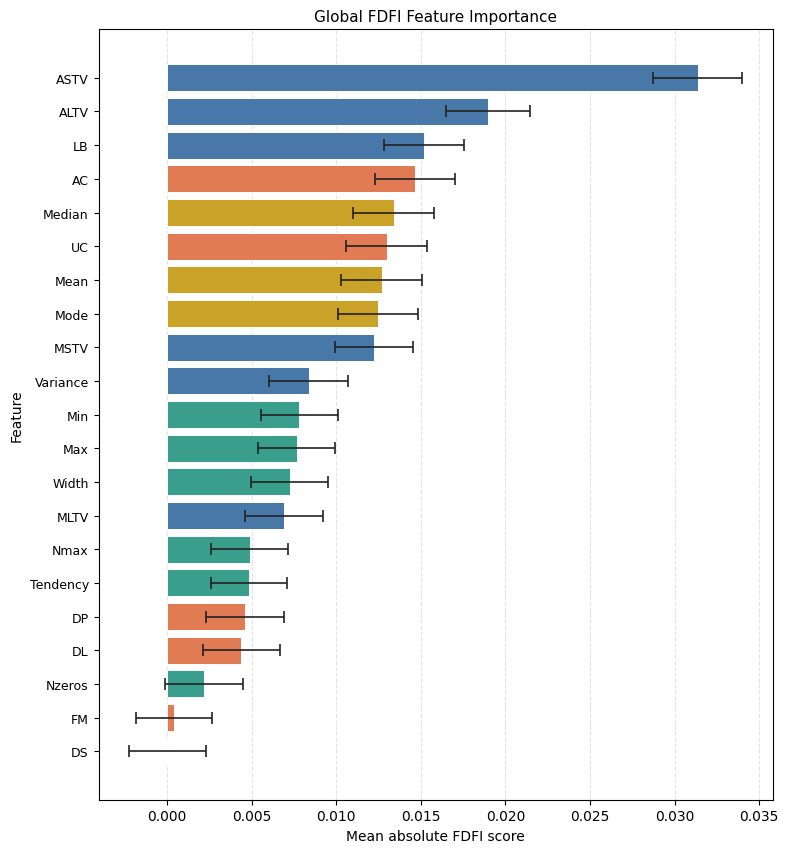

In [7]:
from fdfi.plots import summary_bar

# ── 6.3  Global importance bar chart with error bars ─────────────────────────

# Colour scheme by clinical feature group
GROUP_COLOUR = {
    # FHR baseline & variability
    'LB':       '#4878a8',
    'ASTV':     '#4878a8',
    'MSTV':     '#4878a8',
    'ALTV':     '#4878a8',
    'MLTV':     '#4878a8',
    'Variance': '#4878a8',
    # Accelerations & decelerations
    'AC':       '#e07b54',
    'FM':       '#e07b54',
    'UC':       '#e07b54',
    'DL':       '#e07b54',
    'DS':       '#e07b54',
    'DP':       '#e07b54',
    # Histogram morphology
    'Width':    '#3a9e8c',
    'Min':      '#3a9e8c',
    'Max':      '#3a9e8c',
    'Nmax':     '#3a9e8c',
    'Nzeros':   '#3a9e8c',
    'Tendency': '#3a9e8c',
    # FHR central tendency
    'Mode':     '#c9a227',
    'Mean':     '#c9a227',
    'Median':   '#c9a227',
}

fig, ax, importance_df_sorted = summary_bar(
    global_phi,
    global_se,
    feature_names,
    group_colors=GROUP_COLOUR,
    max_display=len(feature_names),
    savepath='fig2_fdfi_importance.pdf',
)
plt.show()


### 6.1 Group-Level Clinical Inference

The feature-level results can also be aggregated into broad clinical modules. These groups are
used as a compact interpretability layer; they do not change the feature-level estimates used
in Figures 2 and 3.


In [8]:
# ── Group-level clinical inference using fdfi conf_int API ────────────────────
clinical_groups = {
    'FHR baseline & variability': [
        feature_names.index(f) for f in ['LB', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Variance']
    ],
    'Accelerations & decelerations': [
        feature_names.index(f) for f in ['AC', 'FM', 'UC', 'DL', 'DS', 'DP']
    ],
    'Histogram morphology': [
        feature_names.index(f) for f in ['Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Tendency']
    ],
    'FHR central tendency': [
        feature_names.index(f) for f in ['Mode', 'Mean', 'Median']
    ],
}

group_ci = explainer.conf_int(
    alpha=0.05,
    target='X',
    alternative='greater',
    groups=clinical_groups,
    multitest_method='fdr_bh',
)

group_ci_df = (
    pd.DataFrame({
        'group': group_ci['groups'],
        'score': group_ci['score'],
        'se': group_ci['se'],
        'ci_lower': group_ci['ci_lower'],
        'pvalue': group_ci['pvalue'],
        'pvalue_adj': group_ci['pvalue_adj'],
        'reject_fdr': group_ci['reject_null'],
    })
    .sort_values('score', ascending=False)
    .reset_index(drop=True)
)

group_ci_df


,group,score,se,ci_lower,pvalue,pvalue_adj,reject_fdr
0,FHR baseline & variability,0.093066,0.004099,0.086323,0.000000,0.000000,True
1,FHR central tendency,0.038578,0.003433,0.032931,0.500000,0.897635,False
2,Accelerations & decelerations,0.037063,0.003041,0.032060,0.690859,0.897635,False
3,Histogram morphology,0.034685,0.003070,0.029635,0.897635,0.897635,False


### 6.2 Feature-Level Uncertainty with Confidence Intervals

The confidence-interval plot uses the same `ci_df` object as the global importance bar chart.
This means the feature estimates, standard errors, FDR-adjusted rejection decisions, and ranking
come from one full-data FDFI inference result rather than from separately constructed summaries.

The optional per-sample summary plot uses the full `explainer.ueifs_X` matrix. Because many
per-sample attributions are close to zero, the x-axis is adjusted after calling the package
`summary_plot()` helper. The scale change is for readability only; the underlying attribution
values are not transformed.


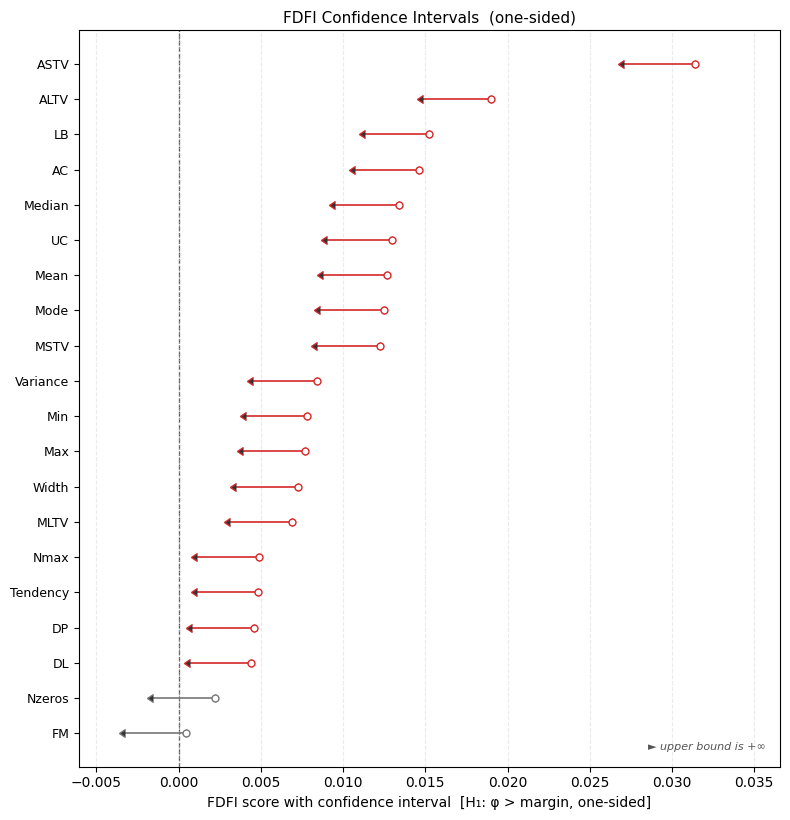

per_sample_phi_X shape: (2126, 21)
min: 1.9728558083764973e-10
percentiles: [1.97285581e-10 5.80166667e-08 1.12927423e-06 5.00719492e-04
 5.00892161e-02 1.56689010e-01 5.45867370e-01]
negative fraction: 0.0
Figure 5 uses log x-axis: xmin=1e-06, xmax=0.245


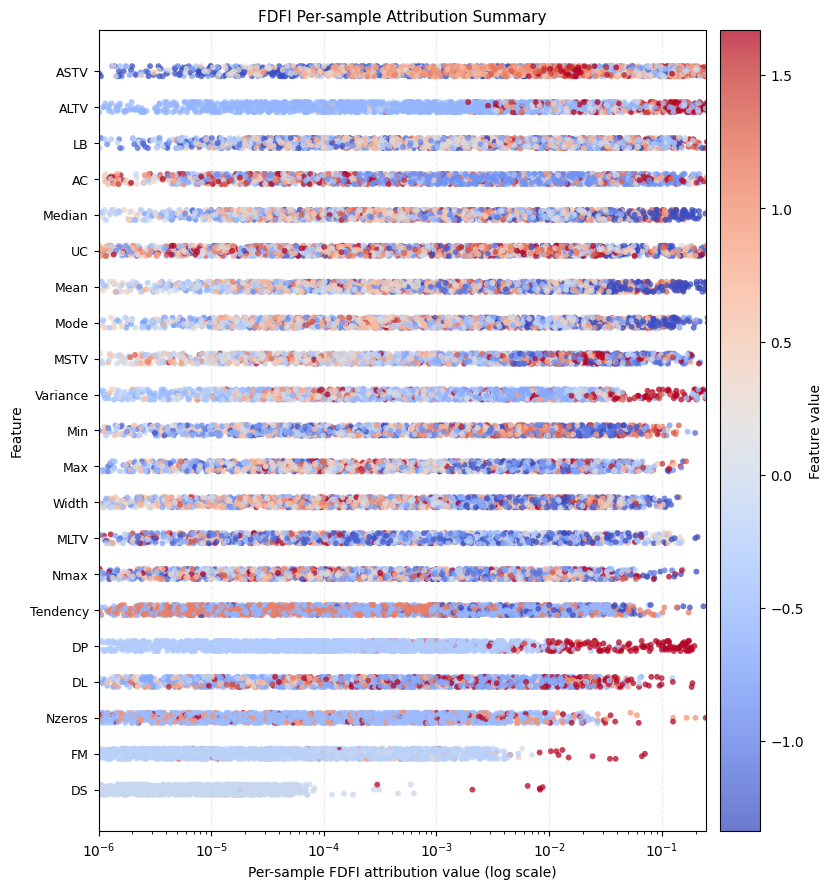

In [9]:
from fdfi.plots import confidence_interval_plot, summary_plot

# ── 6.4  Feature-level confidence intervals using the updated plotting API ────
fig, ax = confidence_interval_plot(
    ci_for_plot,
    feature_names=feature_names,
    max_display=20,
    savepath='fig3_confidence_intervals.pdf',
)
plt.show()

# Optional per-sample attribution summary. The axis scale is chosen from the
# observed full-data attribution matrix and does not change the attribution values.
per_sample_phi_X = np.asarray(explainer.ueifs_X)
finite_vals = per_sample_phi_X[np.isfinite(per_sample_phi_X)]
negative_fraction = float(np.mean(finite_vals < 0)) if finite_vals.size else np.nan

print('per_sample_phi_X shape:', per_sample_phi_X.shape)
print('min:', np.nanmin(per_sample_phi_X))
print('percentiles:', np.nanpercentile(per_sample_phi_X, [0, 1, 5, 50, 95, 99, 100]))
print('negative fraction:', negative_fraction)

fig, ax = summary_plot(
    per_sample_phi_X,
    features=X_values,
    feature_names=feature_names,
    max_display=len(feature_names),
    show=False,
)

if negative_fraction <= 0.001:
    positive_vals = finite_vals[finite_vals > 0]
    xmin = max(float(np.nanpercentile(positive_vals, 1)), 1e-6) if positive_vals.size else 1e-6
    xmax = float(np.nanpercentile(positive_vals, 99.5)) * 1.2 if positive_vals.size else 1.0
    ax.set_xscale('log')
    ax.set_xlim(xmin, xmax)
    ax.set_xlabel('Per-sample FDFI attribution value (log scale)')
    print(f'Figure 5 uses log x-axis: xmin={xmin:.3g}, xmax={xmax:.3g}')
else:
    linthresh = max(float(np.nanpercentile(np.abs(finite_vals), 5)), 1e-6) if finite_vals.size else 1e-6
    lo = float(np.nanpercentile(finite_vals, 0.5)) if finite_vals.size else -1e-6
    hi = float(np.nanpercentile(finite_vals, 99.5)) if finite_vals.size else 1.0
    ax.set_xscale('symlog', linthresh=linthresh)
    ax.set_xlim(lo * 1.2, hi * 1.2)
    ax.set_xlabel('Per-sample FDFI attribution value (symlog scale)')
    print(f'Figure 5 uses symlog x-axis: linthresh={linthresh:.3g}, xlim=({lo * 1.2:.3g}, {hi * 1.2:.3g})')

fig.savefig('fig_optional_summary_plot.pdf', dpi=150, bbox_inches='tight')
plt.show()


---

## 7. Demonstrating Sampling Methods in Latent Space

One of the key strengths of FDFI is its flexibility in **generating counterfactuals** in the
disentangled latent space $\mathcal{Z}$. The library supports multiple sampling strategies:

- **`resample`** (default): Sample counterfactuals from the background training distribution 
  $p(Z)$, yielding estimates that are "typical" under the model's learned distribution.
- **`permutation`**: Permute feature values within the test set itself, creating counterfactuals 
  that stay close to observed data (less extrapolation).
- **`normal`**: Sample from a standard Gaussian $\mathcal{N}(0, I)$, forcing the model to 
  extrapolate to out-of-distribution scenarios (most extreme counterfactuals).

Each method trades off **data fidelity vs. robustness to extrapolation**. In the following section,
we demonstrate all three on a small subset of the full CTG analysis data, showing how
attribution rankings respond to the choice of counterfactual generation.

In [10]:
# ── 7.1  Compare feature importance across sampling methods ──────────────────

# Use a small subset for quick demonstration while keeping the full-data model/background.
N_DEMO = 20
X_demo = X_explain[:N_DEMO]

sampling_methods = ['resample', 'permutation', 'normal']
results_by_method = {}

print('Comparing FDFI attributions across sampling strategies:')
print(f'(on subset of {N_DEMO} CTG instances)\n')

for method in sampling_methods:
    print(f'  Computing with sampling_method="{method}" ...')
    explainer_sm = FlowExplainer(
        model_wrapper,
        X_values,
        sampling_method=method,
        nsamples=50,
    )
    results_by_method[method] = explainer_sm(X_demo)

print('\n' + '=' * 80)
print('Feature Importance Comparison: Sampling Methods')
print('=' * 80)
print(f"{'Feature':>12} {'resample':>15} {'permutation':>15} {'normal':>15}")
print('-' * 80)

for i, fname in enumerate(feature_names):
    r = results_by_method['resample']['phi_X'][i]
    p = results_by_method['permutation']['phi_X'][i]
    n = results_by_method['normal']['phi_X'][i]
    print(f"{fname:>12} {r:>15.6f} {p:>15.6f} {n:>15.6f}")

print('=' * 80)
print('\nInterpretation:')
print('  • Resample:    Uses background training data distribution (most conservative)')
print('  • Permutation: Permutes within the analysis set (minimal extrapolation)')
print('  • Normal:      Samples from standard Gaussian (maximum extrapolation)')


Comparing FDFI attributions across sampling strategies:
(on subset of 20 CTG instances)

  Computing with sampling_method="resample" ...
[FDFI][INFO] Training flow model...


Training complete: 5000 steps, final loss=1.0271


[FDFI][DIAG] Flow Model Diagnostics
[FDFI][DIAG] Latent independence (median dCor): 0.092509 [GOOD]  -> lower is better
[FDFI][DIAG] Distribution fidelity (MMD):       0.031184 [GOOD]  -> lower is better


  Computing with sampling_method="permutation" ...
[FDFI][INFO] Training flow model...


Training complete: 5000 steps, final loss=1.0271


[FDFI][DIAG] Flow Model Diagnostics
[FDFI][DIAG] Latent independence (median dCor): 0.092509 [GOOD]  -> lower is better
[FDFI][DIAG] Distribution fidelity (MMD):       0.031184 [GOOD]  -> lower is better


  Computing with sampling_method="normal" ...
[FDFI][INFO] Training flow model...


Training complete: 5000 steps, final loss=1.0271


[FDFI][DIAG] Flow Model Diagnostics
[FDFI][DIAG] Latent independence (median dCor): 0.092509 [GOOD]  -> lower is better
[FDFI][DIAG] Distribution fidelity (MMD):       0.031184 [GOOD]  -> lower is better



Feature Importance Comparison: Sampling Methods
     Feature        resample     permutation          normal
--------------------------------------------------------------------------------
          LB        0.020577        0.020327        0.023231
          AC        0.025309        0.024752        0.025151
          FM        0.183783        0.162523        0.195355
          UC        0.022926        0.031466        0.025743
          DL        0.016517        0.016257        0.015821
          DS        0.000090        0.000082        0.000080
          DP        0.078480        0.068552        0.073882
        ASTV        0.139755        0.100939        0.146224
        MSTV        0.029863        0.038266        0.034845
        ALTV        0.005899        0.005946        0.005804
        MLTV        0.034033        0.035412        0.033533
       Width        0.018368        0.017300        0.018145
         Min        0.008189        0.008322        0.008475
         Max    

---

## 8. Discussion and Conclusions

This case study has demonstrated the end-to-end workflow of the `fdfi` package on a clinically
relevant, highly collinear dataset for the binary Normal-vs-Other CTG task.

1. **The problem is real.** The Pearson correlation matrix (Figure 1) confirms that FHR
central tendency features (`Mode`, `Mean`, `Median`) are strongly correlated, rendering naïve
feature attribution unreliable when correlation is ignored.

2. **Flow diagnostics certify validity.** MMD and median dCor jointly assess whether the
learned map $T_	heta$ faithfully reconstructs the data distribution and produces an
approximately independent latent representation. Figure 4 is generated with the updated
`diagnostics_plot` helper.

3. **Feature-level inference is aligned across plots.** Figure 2 and Figure 3 use the same
full-data `conf_int()` output. The global bar chart displays the feature-level estimates and
standard errors, while the confidence-interval plot displays the same estimates with interval
bounds and FDR-adjusted rejection status.

4. **Per-sample attribution visualization is optional.** Figure 5 uses the full stored
per-sample UEIF attribution matrix. Its x-axis is adjusted after calling `summary_plot()` to
improve readability for attribution values concentrated near zero; this is a display-only
choice and does not change the FDFI values.
